In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Load preprocessed data
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val   = pd.read_csv('../data/X_val_processed.csv')
X_test  = pd.read_csv('../data/X_test_processed.csv')

y_train = pd.read_csv('../data/y_train.csv')
y_val   = pd.read_csv('../data/y_val.csv')
y_test  = pd.read_csv('../data/y_test.csv')

In [3]:
def to_np_float32(X):
    if isinstance(X, pd.DataFrame):
        return X.to_numpy(dtype=np.float32)
    X = np.asarray(X)
    return X.astype(np.float32)

def to_label_vector(y):
    y = np.asarray(y)
    if y.ndim == 2:
        # If second dimension >1
        if y.shape[1] > 1:
            y = y.argmax(axis=1)
        else:
            y = y[:, 0]
    y = y.reshape(-1)
    if y.dtype.kind not in {"i", "u"}:
        y = y.astype(int)
    return y

X_train_np = to_np_float32(X_train)
X_val_np   = to_np_float32(X_val)
X_test_np  = to_np_float32(X_test)

y_train_np = to_label_vector(y_train)
y_val_np   = to_label_vector(y_val)
y_test_np  = to_label_vector(y_test)

n_features = X_train_np.shape[1]
print(f"#rows train={len(X_train_np)}, #features={n_features}")
pos_rate = y_train_np.mean()
print(f"Positive rate (train): {pos_rate:.3f}")

#rows train=69997, #features=24
Positive rate (train): 0.290


In [4]:
# Normalize layers
norm = layers.Normalization(name="norm")
norm.adapt(X_train_np)

In [ ]:
# Construct class for tokenization for transformer model
class FeatureTokenizer(layers.Layer):

    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model

    def build(self, input_shape):
        f = input_shape[-1]
        self.W = self.add_weight(
            name="W_feat",
            shape=(f, self.d_model),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True,
        )
        self.b = self.add_weight(
            name="b_feat",
            shape=(f, self.d_model),
            initializer=keras.initializers.Zeros(),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        return tf.einsum('bf,fd->bfd', x, self.W) + self.b

In [ ]:
def transformer_block(d_model, num_heads, mlp_ratio=4, dropout=0.35, name=None):
    inp = layers.Input(shape=(None, d_model))
    x = inp
    # PreNorm + MHA
    x1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout)(x1, x1)
    x = layers.Add()([x, attn])
    x = layers.Dropout(dropout)(x)

    # PreNorm + FFN
    x2 = layers.LayerNormalization(epsilon=1e-6)(x)
    hidden = layers.Dense(d_model * mlp_ratio, activation="gelu")(x2)
    hidden = layers.Dropout(dropout)(hidden)
    hidden = layers.Dense(d_model)(hidden)
    x = layers.Add()([x, hidden])
    x = layers.Dropout(dropout)(x)

    return keras.Model(inp, x, name=name)

def build_ft_transformer(
    n_features,
    d_model=64, depth=2, num_heads=4, mlp_ratio=4,
    dropout=0.35, head_hidden=64, norm_layer=None
):
    inp = layers.Input(shape=(n_features,), name="features")
    x = inp

    # Inline normalization
    if norm_layer is not None:
        x = norm_layer(x)

    # Tokenize features
    x = FeatureTokenizer(d_model, name="feat_tok")(x) 

    # Learned [CLS] token
    cls_token = tf.Variable(tf.random.normal([1, 1, d_model]), trainable=True, name="cls_token")
    def prepend_cls(t):
        bsz = tf.shape(t)[0]
        cls = tf.tile(cls_token, [bsz, 1, 1])  
        return tf.concat([cls, t], axis=1)     
    x = layers.Lambda(prepend_cls, name="add_cls")(x)

    # Learnable positional embeddings
    pos_embed = tf.Variable(tf.random.normal([1, n_features + 1, d_model]),
                            trainable=True, name="pos_embed")
    x = x + pos_embed

    # Encoder blocks
    for i in range(depth):
        x = transformer_block(d_model, num_heads, mlp_ratio, dropout, name=f"enc_{i+1}")(x)

    # CLS pooling
    cls = layers.Lambda(lambda t: t[:, 0, :], name="cls_pool")(x)

    # Head
    h = layers.LayerNormalization(epsilon=1e-6)(cls)
    h = layers.Dense(head_hidden, activation="gelu",
                     kernel_regularizer=keras.regularizers.l2(1e-5))(h)
    h = layers.Dropout(dropout)(h)
    out = layers.Dense(1, activation="sigmoid", name="prob")(h)

    return keras.Model(inp, out, name="FTTransformer")

In [7]:
def binary_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, eps, 1. - eps)
        pt = tf.where(tf.equal(y_true, 1.), y_pred, 1. - y_pred)
        w = tf.where(tf.equal(y_true, 1.), alpha, 1. - alpha)
        return -tf.reduce_mean(w * tf.pow(1. - pt, gamma) * tf.math.log(pt))
    return loss

In [8]:
use_focal = True  # set False to use plain BCE

In [9]:
X_train.shape

(69997, 24)

In [10]:
model = build_ft_transformer(
    n_features=n_features,
    d_model=64, depth=2, num_heads=4,
    mlp_ratio=4, dropout=0.35, head_hidden=64,
    norm_layer=norm
)

schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-4,
    first_decay_steps=5 * int(np.ceil(len(X_train_np)/512)),
    t_mul=2.0, m_mul=0.9
)
opt = keras.optimizers.AdamW(learning_rate=schedule, weight_decay=1e-4)

Class weights (if used): {0: 0.7041951710261569, 1: 1.7243188648568755}


In [13]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="acc")]
)

def to_label_vector(y):
    y = np.asarray(y)
    # If one-hot onvert to class index
    if y.ndim == 2 and y.shape[1] > 1:
        y = y.argmax(axis=1)
    # Squeeze to 1-D
    y = y.reshape(-1)
    # Cast to int 
    if y.dtype.kind not in {"i", "u"}:
        y = y.astype(int)
    return y

y_train_labels = to_label_vector(y_train)
y_val_labels   = to_label_vector(y_val)
y_test_labels  = to_label_vector(y_test)

classes = np.unique(y_train_labels)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_labels
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("Class weights:", class_weight_dict)

# Setup callbacks
es = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    restore_best_weights=True
)
rlr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

Class weights: {0: 0.7041951710261569, 1: 1.7243188648568755}


In [14]:
hist = model.fit(
    X_train_np, y_train_np,
    validation_data=(X_val_np, y_val_np),
    epochs= 5,
    batch_size= 150,
    callbacks=[es, rlr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/5
467/467 ━━━━━━━━━━━━━━━━━━━━ 51s 103ms/step - acc: 0.5060 - auc: 0.5006 - loss: 0.7624 - val_acc: 0.2900 - val_auc: 0.6784 - val_loss: 0.6999 - learning_rate: 1.0000e-04
Epoch 2/5
467/467 ━━━━━━━━━━━━━━━━━━━━ 50s 107ms/step - acc: 0.5487 - auc: 0.5810 - loss: 0.6915 - val_acc: 0.7350 - val_auc: 0.7644 - val_loss: 0.5536 - learning_rate: 1.0000e-04
Epoch 3/5
467/467 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - acc: 0.7002 - auc: 0.7383 - loss: 0.6092 - val_acc: 0.7904 - val_auc: 0.7833 - val_loss: 0.5442 - learning_rate: 1.0000e-04
Epoch 4/5
467/467 ━━━━━━━━━━━━━━━━━━━━ 54s 117ms/step - acc: 0.7577 - auc: 0.7698 - loss: 0.5708 - val_acc: 0.7860 - val_auc: 0.7973 - val_loss: 0.5383 - learning_rate: 1.0000e-04
Epoch 5/5
467/467 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - acc: 0.7708 - auc: 0.7799 - loss: 0.5539 - val_acc: 0.7852 - val_auc: 0.8137 - val_loss: 0.5421 - learning_rate: 1.0000e-04


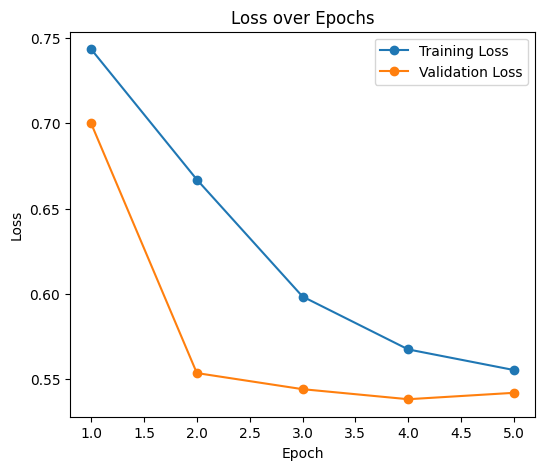

In [15]:
#Evaluate
metrics = hist.history
num_epochs = range(1, 6) # 5 epochs 
# Loss plots
plt.figure(figsize = (6, 5))
plt.plot(num_epochs, metrics['loss'], label = 'Training Loss', marker = 'o')
plt.plot(num_epochs, metrics['val_loss'], label = 'Validation Loss', marker = 'o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

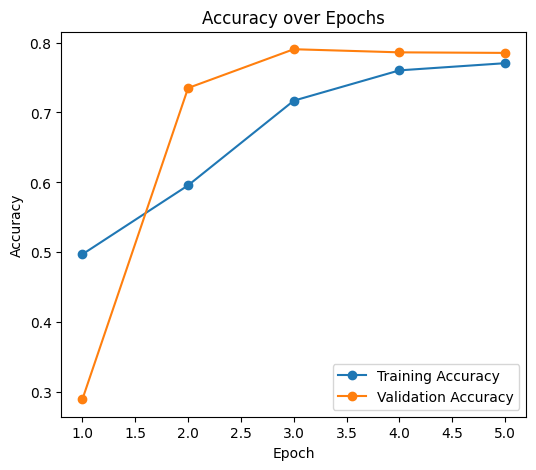

In [16]:
# Accuracy plots
plt.figure(figsize = (6, 5))
plt.plot(num_epochs, metrics['acc'], label = 'Training Accuracy', marker = 'o')
plt.plot(num_epochs, metrics['val_acc'], label = 'Validation Accuracy', marker = 'o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.show()

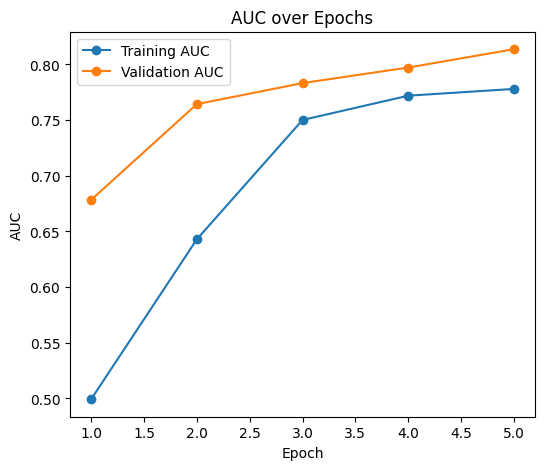

In [17]:
# AUC plots
plt.figure(figsize = (6, 5))
plt.plot(num_epochs, metrics['auc'], label = 'Training AUC', marker = 'o')
plt.plot(num_epochs, metrics['val_auc'], label = 'Validation AUC', marker = 'o')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('AUC over Epochs')
plt.legend()
plt.show()

101/101 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
Best threshold on val (F1): 0.7223 | F1=0.6764 | P=0.6103 | R=0.7587
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


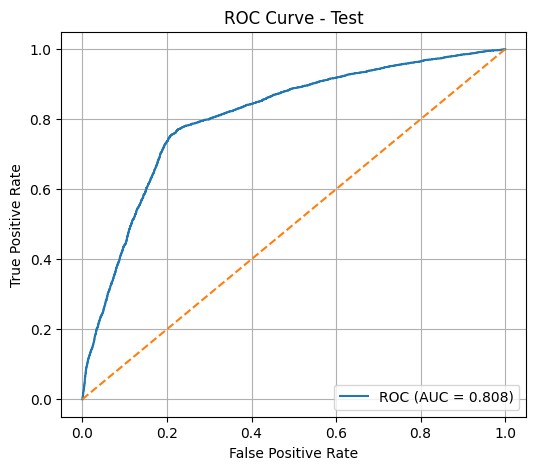

In [23]:
# Evaluate on test set and plot results
y_val_prob = model.predict(X_val_np, batch_size= 150).ravel()


prec, rec, thr = precision_recall_curve(y_val_np, y_val_prob)
f1s = 2*prec*rec/(prec+rec+1e-9)
best_idx = f1s.argmax()
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"Best threshold on val (F1): {best_thr:.4f} | F1={f1s[best_idx]:.4f} | P={prec[best_idx]:.4f} | R={rec[best_idx]:.4f}")

# 2) ROC on test (no threshold needed)
y_test_prob = model.predict(X_test_np, batch_size= 150).ravel()
fpr, tpr, _ = roc_curve(y_test_np, y_test_prob)
auc_score = roc_auc_score(y_test_np, y_test_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test"); plt.legend(loc="lower right"); plt.grid(True)
plt.show()

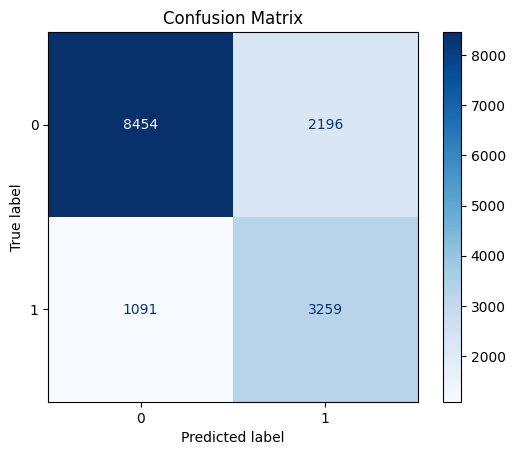

In [25]:
# Confusion Matrix
y_test_pred = (y_test_prob >= best_thr).astype(int)
cm = confusion_matrix(y_test_np, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(values_format="d", cmap="Blues")
plt.title(f"Confusion Matrix")
plt.show()